In [16]:
%pip install -r requirements.txt --quiet

Note: you may need to restart the kernel to use updated packages.


In [31]:
import os
import pandas as pd
from omegaconf import OmegaConf
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
pd.set_option('display.max_columns', None)

In [66]:
# Read pickles from the path specified in config.dest_file
from os import makedirs


config_path = "config_data_processing.yaml"  # Replace with the path to your config file
config = OmegaConf.load(config_path)
df_encoded_path = os.path.join(config.dest_file, "df_encoded.csv")

# Fix: If 'outputs' is not in config, create it based on dest_file
outputs_path = os.path.join(config.outputs, "outputs")
makedirs(outputs_path, exist_ok=True)
df = pd.read_csv(df_encoded_path)

In [10]:
df.head(-5)

,surfaceProcessingLocationCavity,hotRunner,hotRunnerCost,manufacturingCost,mouldValidationCost,designTime,hourlyDesignCost,removedChassis,weightChassisProcessed,surfaceProcessingLocationChassis,removedCavity,numberOfCavities,weightCavityProcessed,weightMould,totalTransportationPercentage,percentageAircraft,percentageLorry,percentageTrain,percentageShip,totalDistance,transportCost,injectedMaterial_product,injectedMaterialCost,percentageRecycledMaterial,maxDepth,maxWallThickness,productVolume,materozzaVolume,nAnniProduzione,nProdottiAnno,materialDensity,tolerance,surfaceFinishing,cycleTime,machineCycleTime,maintenanceCost,productionCost,injectedMaterial_materozza,injectionMouldingProcess,memtiEngineValue,steelPrice,runnersType,mouldMaterialName,machineName,EUUSMacchina,CNMacchina,gateDiameter,setupTime,warmupTime,deliveryVolume,deliveryPeriod,mouldDesignCostDisplay,mouldTotalCost,Cost,human health - photochemical oxidation,ecosystem quality - terrestrial ecotoxicity,resources - mineral extraction,resources - non-renewable energy,ecosystem quality - terrestrial acidification & nutrification,resources - total,human health - ionising radiation,human health - respiratory effects (inorganics),human health - total,human health - human toxicity,ecosystem quality - aquatic ecotoxicity,climate change - climate change,human health - ozone layer depletion,ecosystem quality - land occupation,climate change - total,ecosystem quality - total
0,3.0,1.0,3.0,2.0,0.0,3.0,2.0,3.0,1.0,0.0,4.0,3.0,2.0,2.0,0.0,2.0,0.0,0.0,1.0,2.0,1.0,3.0,1.0,0.0,2.0,0.0,3.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,3.0,0.0,3.0,2.0,0.0,0.0,1.0,6.0,7.0,4.0,4.0,0.0,2.0,1.0,0.0,3.0,0.0,1.0,56093.360588,0.000005,0.000885,0.000019,0.001452,0.000023,0.001471,0.000599,0.002724,0.004244,0.000916,0.000017,0.001938,1.483623e-07,0.000036,0.001938,0.000961
1,3.0,1.0,3.0,1.0,2.0,4.0,1.0,1.0,1.0,0.0,4.0,1.0,2.0,2.0,0.0,2.0,0.0,0.0,1.0,2.0,1.0,3.0,1.0,0.0,2.0,0.0,3.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,3.0,0.0,3.0,2.0,0.0,0.0,1.0,6.0,7.0,4.0,4.0,0.0,2.0,1.0,0.0,3.0,0.0,1.0,43493.360588,0.000004,0.000805,0.000018,0.001366,0.000022,0.001384,0.000567,0.002586,0.004010,0.000853,0.000016,0.001825,1.379114e-07,0.000032,0.001825,0.000874
2,3.0,0.0,3.0,2.0,3.0,2.0,2.0,3.0,1.0,0.0,2.0,3.0,2.0,2.0,0.0,2.0,0.0,0.0,1.0,2.0,1.0,3.0,1.0,0.0,2.0,0.0,3.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,3.0,0.0,3.0,2.0,0.0,0.0,1.0,6.0,7.0,4.0,4.0,0.0,2.0,1.0,0.0,3.0,0.0,1.0,102993.360588,0.000005,0.000885,0.000019,0.001452,0.000023,0.001470,0.000599,0.002723,0.004243,0.000916,0.000017,0.001938,1.483223e-07,0.000036,0.001938,0.000960
3,3.0,1.0,1.0,1.0,3.0,4.0,1.0,2.0,1.0,0.0,4.0,3.0,2.0,2.0,0.0,2.0,0.0,0.0,1.0,2.0,1.0,3.0,1.0,0.0,2.0,0.0,3.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,3.0,0.0,3.0,2.0,0.0,0.0,1.0,6.0,7.0,4.0,4.0,0.0,2.0,1.0,0.0,3.0,0.0,1.0,44993.360588,0.000004,0.000853,0.000018,0.001414,0.000022,0.001432,0.000584,0.002666,0.004146,0.000891,0.000017,0.001891,1.439857e-07,0.000034,0.001891,0.000926
4,3.0,0.0,2.0,1.0,2.0,3.0,2.0,2.0,1.0,0.0,2.0,3.0,2.0,2.0,0.0,2.0,0.0,0.0,1.0,2.0,1.0,3.0,1.0,0.0,2.0,0.0,3.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,3.0,0.0,3.0,2.0,0.0,0.0,1.0,6.0,7.0,4.0,4.0,0.0,2.0,1.0,0.0,3.0,0.0,1.0,67593.360588,0.000004,0.000852,0.000018,0.001414,0.000022,0.001432,0.000584,0.002666,0.004145,0.000890,0.000017,0.001890,1.439457e-07,0.000034,0.001890,0.000925
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164138,2.0,0.0,3.0,1.0,0.0,3.0,1.0,1.0,1.0,3.0,2.0,0.0,2.0,2.0,0.0,2.0,0.0,0.0,1.0,2.0,1.0,3.0,1.0,0.0,2.0,0.0,3.0,0.0,0.0,0.0,2.0,0.0,0.0,1.0,0.0,3.0,7.0,3.0,3.0,0.0,0.0,1.0,6.0,6.0,2.0,4.0,0.0,1.0,1.0,0.0,3.0,0.0,1.0,80493.410588,0.000005,0.002183,0.000019,0.003471,0.000036,0.003490,0.001876,0.003970,0.007019,0.001168,0.000041,0.003177,2.562055e-07,0.000051,0.003177,0.002311
164139,2.0

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 164148 entries, 0 to 164147
Data columns (total 70 columns):
 #   Column                                                         Non-Null Count   Dtype  
---  ------                                                         --------------   -----  
 0   surfaceProcessingLocationCavity                                164148 non-null  float64
 1   hotRunner                                                      164148 non-null  float64
 2   hotRunnerCost                                                  164148 non-null  float64
 3   manufacturingCost                                              164148 non-null  float64
 4   mouldValidationCost                                            164148 non-null  float64
 5   designTime                                                     164148 non-null  float64
 6   hourlyDesignCost                                               164148 non-null  float64
 7   removedChassis                                 

In [21]:
df.describe()

,surfaceProcessingLocationCavity,hotRunner,hotRunnerCost,manufacturingCost,mouldValidationCost,designTime,hourlyDesignCost,removedChassis,weightChassisProcessed,surfaceProcessingLocationChassis,removedCavity,numberOfCavities,weightCavityProcessed,weightMould,totalTransportationPercentage,percentageAircraft,percentageLorry,percentageTrain,percentageShip,totalDistance,transportCost,injectedMaterial_product,injectedMaterialCost,percentageRecycledMaterial,maxDepth,maxWallThickness,productVolume,materozzaVolume,nAnniProduzione,nProdottiAnno,materialDensity,tolerance,surfaceFinishing,cycleTime,machineCycleTime,maintenanceCost,productionCost,injectedMaterial_materozza,injectionMouldingProcess,memtiEngineValue,steelPrice,runnersType,mouldMaterialName,machineName,EUUSMacchina,CNMacchina,gateDiameter,setupTime,warmupTime,deliveryVolume,deliveryPeriod,mouldDesignCostDisplay,mouldTotalCost,Cost,human health - photochemical oxidation,ecosystem quality - terrestrial ecotoxicity,resources - mineral extraction,resources - non-renewable energy,ecosystem quality - terrestrial acidification & nutrification,resources - total,human health - ionising radiation,human health - respiratory effects (inorganics),human health - total,human health - human toxicity,ecosystem quality - aquatic ecotoxicity,climate change - climate change,human health - ozone layer depletion,ecosystem quality - land occupation,climate change - total,ecosystem quality - total
count,164148.000000,164148.000000,164148.000000,164148.000000,164148.000000,164148.000000,164148.000000,164148.000000,164148.0,164148.000000,164148.000000,164148.000000,164148.0,164148.0,164148.0,164148.0,164148.0,164148.0,164148.0,164148.000000,164148.0,164148.000000,164148.000000,164148.000000,164148.000000,164148.000000,164148.000000,164148.000000,164148.0,164148.000000,164148.000000,164148.000000,164148.000000,164148.0,164148.000000,164148.000000,164148.000000,164148.000000,164148.000000,164148.0,164148.000000,164148.0,164148.000000,164148.000000,164148.00000,164148.000000,164148.0,164148.000000,164148.0,164148.000000,164148.000000,164148.0,164148.0,164148.000000,164148.000000,164148.000000,164148.000000,164148.000000,164148.000000,164148.000000,164148.000000,164148.000000,164148.000000,164148.000000,164148.000000,164148.000000,1.641480e+05,164148.000000,164148.000000,164148.000000
mean,3.000000,0.195409,1.390818,1.781472,0.118430,3.000000,1.035529,1.497405,1.0,0.769793,2.071058,0.284231,2.0,2.0,0.0,2.0,0.0,0.0,1.0,2.000244,1.0,3.455528,1.318980,0.461194,2.318584,0.159868,2.681020,0.957234,0.0,0.107616,2.410112,0.073738,0.124497,1.0,0.217377,2.781466,3.884501,3.501060,2.076979,0.0,0.426347,1.0,5.818901,9.061274,5.43275,4.115469,0.0,2.000085,1.0,0.365713,2.890392,0.0,1.0,66584.271435,0.000040,0.003328,0.000024,0.030269,0.000185,0.030294,0.006191,0.014077,0.023236,0.002927,0.000106,0.019277,1.373095e-06,0.000173,0.019277,0.003792
std,0.554905,0.396516,0.706136,0.831962,0.542119,0.510438,0.185113,0.967931,0.0,1.186966,0.336721,0.918134,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.460903,0.0,1.700838,0.655776,0.498493,0.655063,0.366485,0.655758,1.398362,0.0,0.309896,1.269328,0.340627,0.553023,0.0,0.560843,0.623950,4.540238,1.647026,0.525674,0.0,1.047509,0.0,1.404725,4.282591,3.29176,0.933774,0.0,0.598877,0.0,0.904133,0.312402,0.0,0.0,15482.078690,0.000101,0.005769,0.000017,0.080793,0.000451,0.080809,0.015016,0.031402,0.051850,0.005354,0.000233,0.048485,3.047302e-06,0.000378,0.048485,0.006825
min,2.000000,0.000000,1.000000,1.000000,0.000000,2.000000,1.000000,1.000000,1.0,0.000000,2.000000,0.000000,2.0,2.0,0.0,2.0,0.0,0.0,1.0,1.000000,1.0,0.000000,1.000000,0.000000,2.000000,0.000000,1.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,1.0,0.000000,1.000000,0.000000,0.000000,1.000000,0.0,0.000000,1.0,2.000000,2.000000,0.00000,1.000000,0.0,1.000000,1.0,0.000000,2.000000,0.0,1.0,40493.360588,0.000004,0.000804,0.000018,0.001357,0.000022,0.001374,0.000561,0.002580,0.003998,0.000852,0.000016,0.001819,1.373808e-07,0.000032,

In [13]:
df.columns

Index(['surfaceProcessingLocationCavity', 'hotRunner', 'hotRunnerCost',
       'manufacturingCost', 'mouldValidationCost', 'designTime',
       'hourlyDesignCost', 'removedChassis', 'weightChassisProcessed',
       'surfaceProcessingLocationChassis', 'removedCavity', 'numberOfCavities',
       'weightCavityProcessed', 'weightMould', 'totalTransportationPercentage',
       'percentageAircraft', 'percentageLorry', 'percentageTrain',
       'percentageShip', 'totalDistance', 'transportCost',
       'injectedMaterial_product', 'injectedMaterialCost',
       'percentageRecycledMaterial', 'maxDepth', 'maxWallThickness',
       'productVolume', 'materozzaVolume', 'nAnniProduzione', 'nProdottiAnno',
       'materialDensity', 'tolerance', 'surfaceFinishing', 'cycleTime',
       'machineCycleTime', 'maintenanceCost', 'productionCost',
       'injectedMaterial_materozza', 'injectionMouldingProcess',
       'memtiEngineValue', 'steelPrice', 'runnersType', 'mouldMaterialName',
       'machineName',

In [26]:
df.shape

(164148, 70)

In [14]:
df_corr = df.corr()

In [11]:
#['surfaceProcessingLocationCavity', 'surfaceProcessingLocationChassis', 'injectedMaterial_product', 'injectedMaterial_materozza', 'injectionMouldingProcess','memtiEngineValue', 'steelPrice', 'runnersType', 'mouldMaterialName','machineName', 'EUUSMacchina', 'CNMacchina']

In [32]:
df_corr[df_corr.columns] = df_corr[df_corr.columns].astype(float)

In [33]:
scaler = MinMaxScaler()
scalerStd = StandardScaler()

In [34]:
# scaling the data
df_scaled = pd.DataFrame(scaler.fit_transform(df), columns=df.columns, index=df.index)

In [58]:
df_scaled_path = os.path.join(config.dest_file, "df_scaled.csv")
df_scaled.to_csv(df_scaled_path, index=False)

In [59]:
df_scaled_path = os.path.join(config.dest_file, "df_scaled.csv")
df_scaled=pd.read_csv(df_scaled_path)

In [60]:
df_scaled = pd.DataFrame(scaler.fit_transform(df_scaled), columns=df_scaled.columns, index=df_scaled.index)

# Correlations Using Dcor


In [112]:
import dcor
import numpy as np
import pandas as pd
from joblib import Parallel, delayed

# Function to compute distance correlation for a pair of columns
def compute_distance_correlation(col1, col2):
    dc = dcor.distance_correlation(col1, col2)
    return min(max(dc, 0.0), 1.0)  # clamp to [0,1] for numerical safety

# Function to calculate distance correlation matrix with categorical handling
def distance_correlation_matrix_parallel(df, n_jobs=-1):
    # One-hot encode categorical variables
    df_encoded = pd.get_dummies(df, drop_first=False)
    
    num_vars = df_encoded.shape[1]
    corr_matrix = np.zeros((num_vars, num_vars))
    
    results = Parallel(n_jobs=n_jobs)(
        delayed(compute_distance_correlation)(df_encoded.iloc[:, i].values, df_encoded.iloc[:, j].values)
        for i in range(num_vars) for j in range(num_vars)
    )
    
    # Fill the correlation matrix
    for idx, (i, j) in enumerate([(i, j) for i in range(num_vars) for j in range(num_vars)]):
        corr_matrix[i, j] = results[idx]
    
    return pd.DataFrame(corr_matrix, index=df_encoded.columns, columns=df_encoded.columns)
# Function to filter variables by distance correlation threshold
def filter_variables_by_distance_correlation_parallel(df, threshold=0.43, n_jobs=-1):
    corr_df = distance_correlation_matrix_parallel(df, n_jobs=n_jobs)
    filtered_corr_df = corr_df.where(corr_df >= threshold, 0)
    return filtered_corr_df

def plot_and_save_corr(filtered_corr_df, filter_threshold, output_dir):
        # Plot the filtered heatmap
    filtered_corr_df = filtered_corr_df.loc[(filtered_corr_df != filter_threshold).any(axis=1), (filtered_corr_df != filter_threshold).any(axis=0)]
    plt.figure(figsize=(50, 30))
    sns.heatmap(filtered_corr_df, annot=True, cmap='coolwarm', vmin=0, vmax=1)
    plt.title(f"Filtered Distance Correlation Heatmap (Threshold ≥ {filter_threshold})")
    #save 
    plt.savefig(os.path.join(config.outputs, f"dcor_corr_graph_{filter_threshold}.png"))
    plt.show()



In [40]:
filtered_corr_df_one_hot = filter_variables_by_distance_correlation_parallel(df, threshold=0, n_jobs=-1)
filtered_corr_df_one_hot_path = os.path.join(config.dest_file, "df_filtered_one_hot.csv")
filtered_corr_df_one_hot.to_csv(filtered_corr_df_one_hot_path)

In [41]:
filtered_corr_df= filtered_corr_df_one_hot

In [55]:
filtered_corr_df_one_hot_path = os.path.join(config.dest_file, "df_filtered_one_hot.csv")

filtered_corr_df = pd.read_csv(filtered_corr_df_one_hot_path)

In [56]:
# Remove rows and columns that are all zeros (no significant correlations)
filtered_corr_df = filtered_corr_df.loc[(filtered_corr_df != 0).any(axis=1), (filtered_corr_df != 0).any(axis=0)]

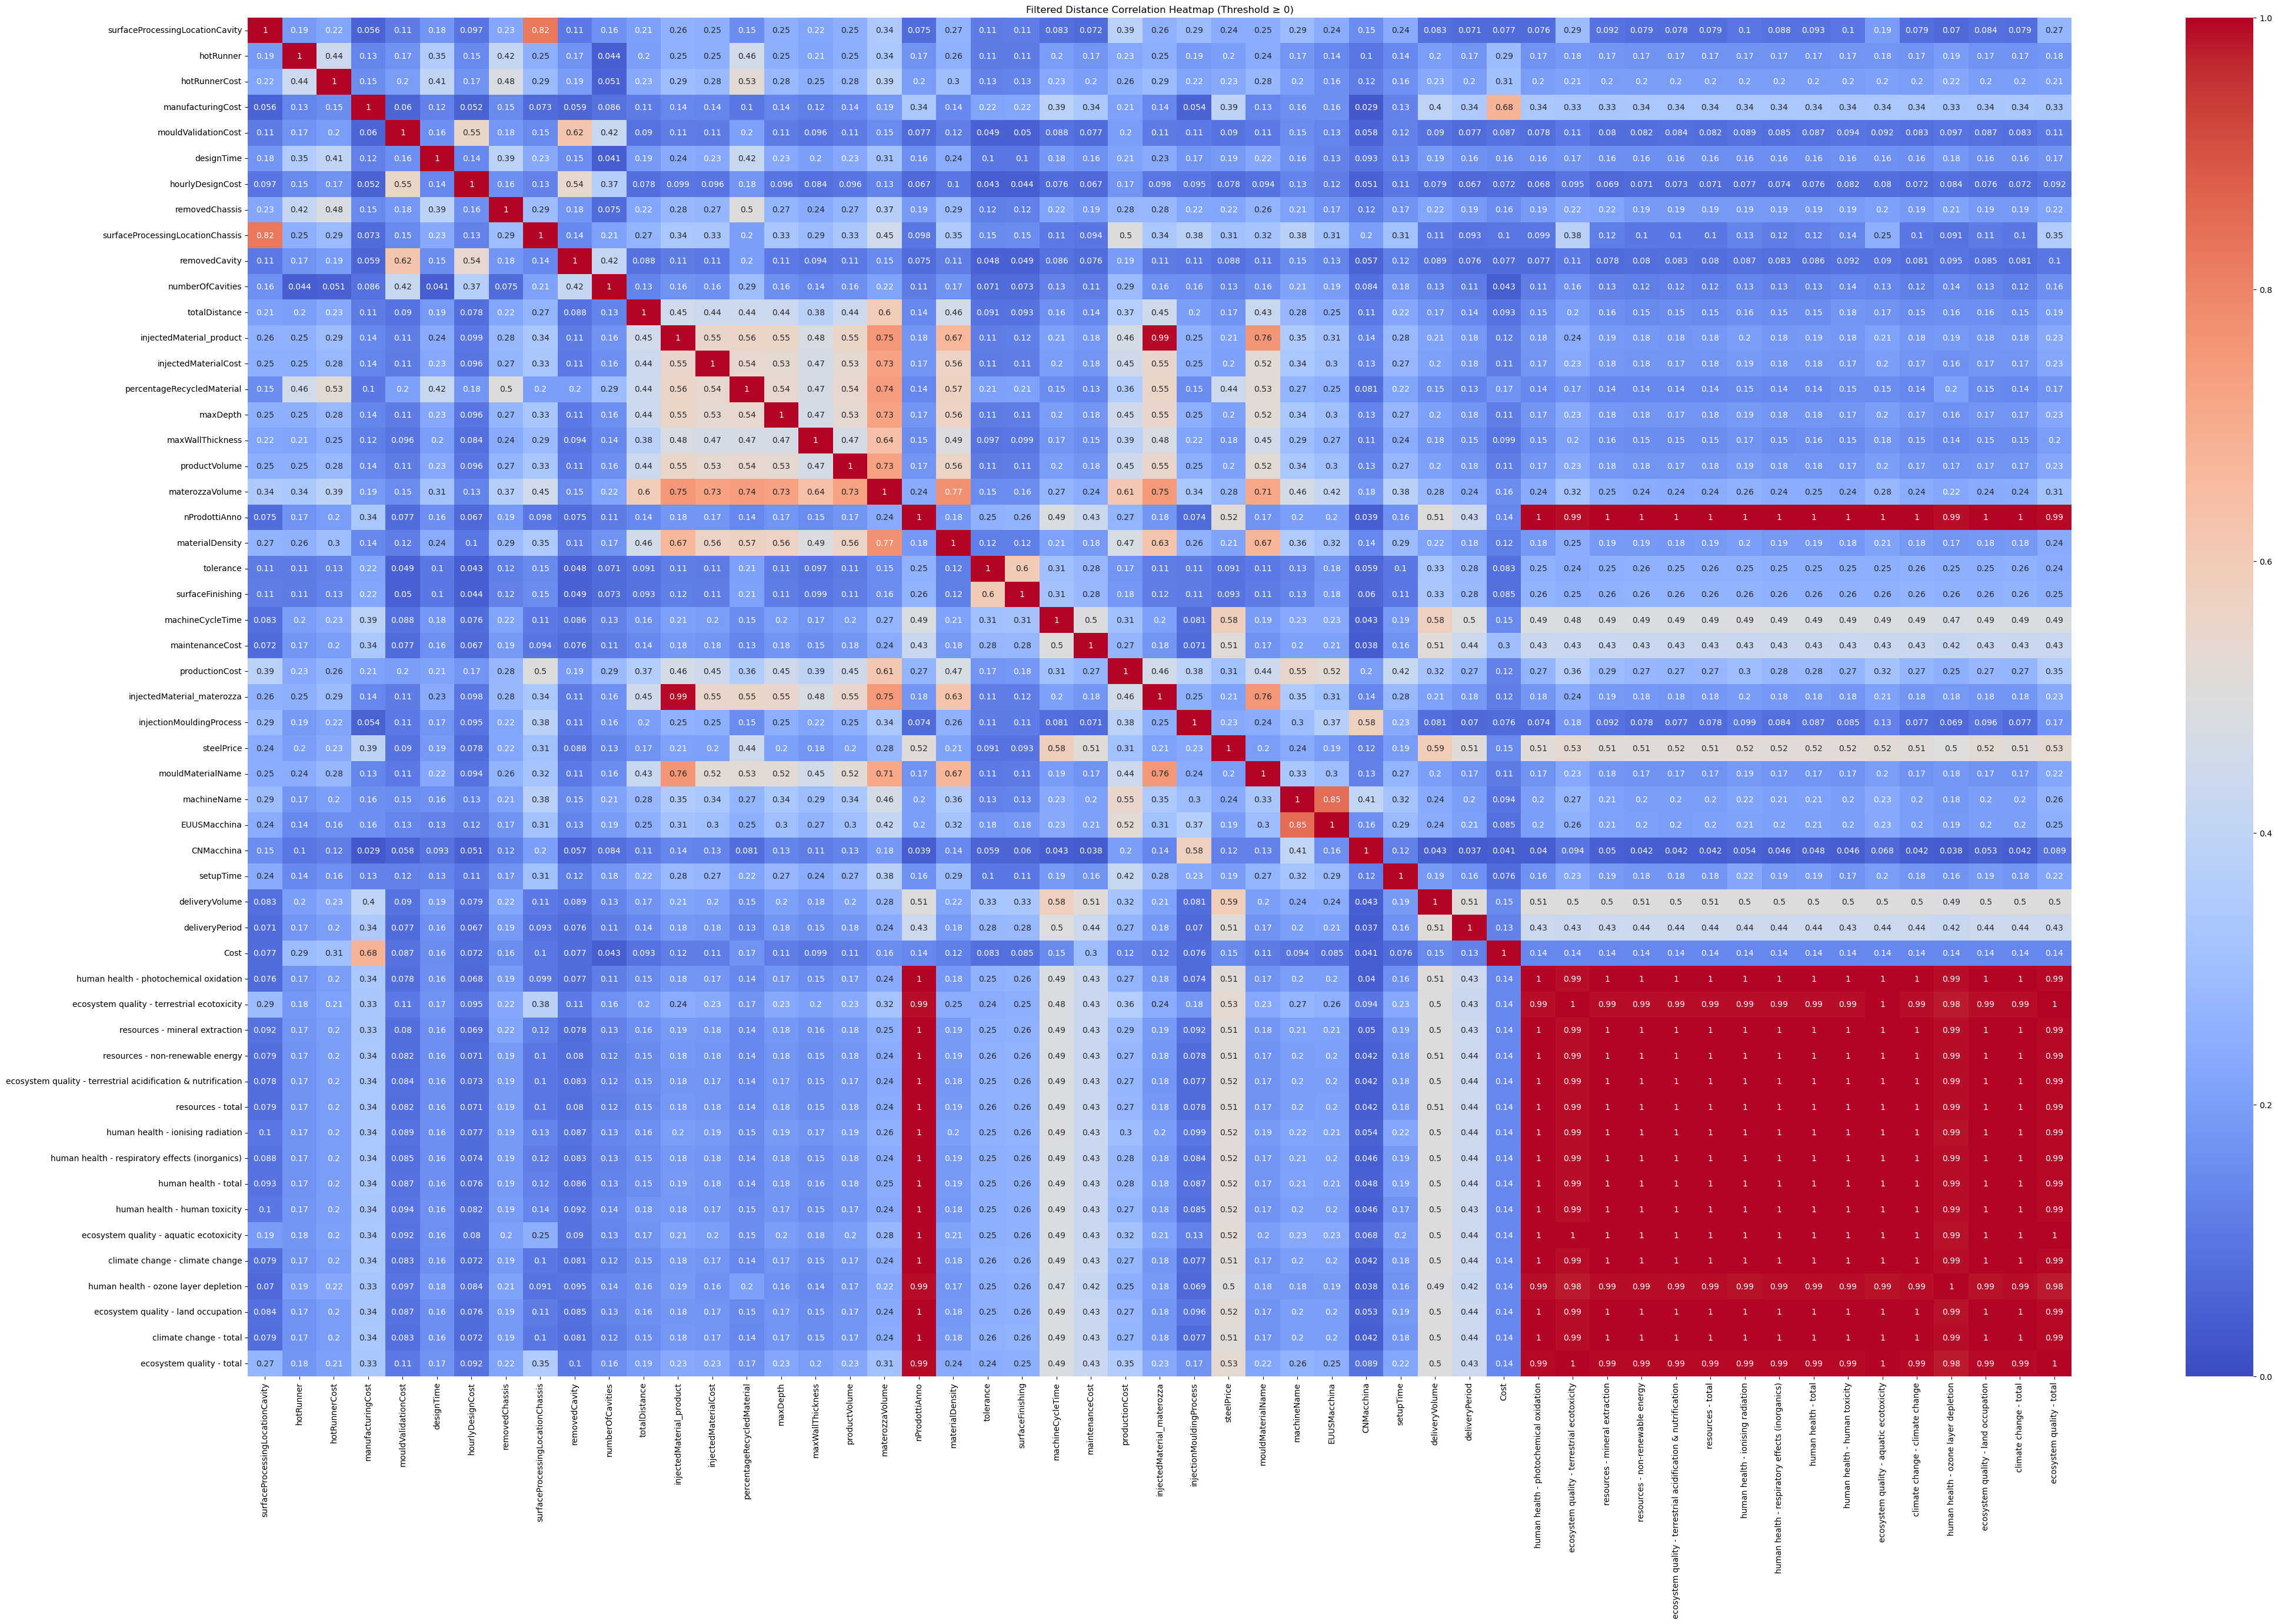

In [113]:
plot_and_save_corr(filtered_corr_df_one_hot, 0, outputs_path)

In [38]:
feature_column = ['surfaceProcessingLocationCavity', 'hotRunner', 'hotRunnerCost',
       'manufacturingCost', 'mouldValidationCost', 'designTime',
       'hourlyDesignCost', 'removedChassis', 'weightChassisProcessed',
       'surfaceProcessingLocationChassis', 'removedCavity', 'numberOfCavities',
       'weightCavityProcessed', 'weightMould', 'totalTransportationPercentage',
       'percentageAircraft', 'percentageLorry', 'percentageTrain',
       'percentageShip', 'totalDistance', 'transportCost',
       'injectedMaterial_product', 'injectedMaterialCost',
       'percentageRecycledMaterial', 'maxDepth', 'maxWallThickness',
       'productVolume', 'materozzaVolume', 'nAnniProduzione', 'nProdottiAnno',
       'materialDensity', 'tolerance', 'surfaceFinishing', 'cycleTime',
       'machineCycleTime', 'maintenanceCost', 'productionCost',
       'injectedMaterial_materozza', 'injectionMouldingProcess',
       'memtiEngineValue', 'steelPrice', 'runnersType', 'mouldMaterialName',
       'machineName', 'EUUSMacchina', 'CNMacchina', 'gateDiameter',
       'setupTime', 'warmupTime', 'deliveryVolume', 'deliveryPeriod',
       'mouldDesignCostDisplay', 'mouldTotalCost']

target_column = ['Cost',
       'human health - photochemical oxidation',
       'ecosystem quality - terrestrial ecotoxicity',
       'resources - mineral extraction', 'resources - non-renewable energy',
       'ecosystem quality - terrestrial acidification & nutrification',
       'resources - total', 'human health - ionising radiation',
       'human health - respiratory effects (inorganics)',
       'human health - total', 'human health - human toxicity',
       'ecosystem quality - aquatic ecotoxicity',
       'climate change - climate change',
       'human health - ozone layer depletion',
       'ecosystem quality - land occupation', 'climate change - total',
       'ecosystem quality - total']

We will divide the columns into features and target. and delete the highly correlated ones. 

In [98]:
(filtered_corr_df.columns)

Index(['Unnamed: 0', 'surfaceProcessingLocationCavity', 'hotRunner',
       'hotRunnerCost', 'manufacturingCost', 'mouldValidationCost',
       'designTime', 'hourlyDesignCost', 'removedChassis',
       'surfaceProcessingLocationChassis', 'removedCavity', 'numberOfCavities',
       'totalDistance', 'injectedMaterial_product', 'injectedMaterialCost',
       'percentageRecycledMaterial', 'maxDepth', 'maxWallThickness',
       'productVolume', 'materozzaVolume', 'nProdottiAnno', 'materialDensity',
       'tolerance', 'surfaceFinishing', 'machineCycleTime', 'maintenanceCost',
       'productionCost', 'injectedMaterial_materozza',
       'injectionMouldingProcess', 'steelPrice', 'mouldMaterialName',
       'machineName', 'EUUSMacchina', 'CNMacchina', 'setupTime',
       'deliveryVolume', 'deliveryPeriod', 'Cost',
       'human health - photochemical oxidation',
       'ecosystem quality - terrestrial ecotoxicity',
       'resources - mineral extraction', 'resources - non-renewable energy',


In [68]:
# Find non-numeric columns
non_numeric_columns = filtered_corr_df.select_dtypes(exclude=[float, int]).columns
print("Non-numeric columns:", non_numeric_columns)

Non-numeric columns: Index(['Unnamed: 0'], dtype='object')


In [41]:
#df_scaled= pd.read_csv('out11.csv')

In [72]:
input_variables= ['surfaceProcessingLocationCavity', 'hotRunner',
'hotRunnerCost','manufacturingCost', 'mouldValidationCost',
'designTime','hourlyDesignCost', 'removedChassis', 'weightChassisProcessed',
'surfaceProcessingLocationChassis', 'removedCavity', 'numberOfCavities',
'weightCavityProcessed', 'weightMould',
'totalTransportationPercentage','percentageAircraft', 'percentageLorry', 'percentageTrain','percentageShip', 'totalDistance',
'injectedMaterial_product', 'injectedMaterialCost','percentageRecycledMaterial', 'maxDepth', 'maxWallThickness','productVolume', 'materozzaVolume', 'nAnniProduzione', 'nProdottiAnno',
 'materialDensity', 'tolerance', 'surfaceFinishing', 'cycleTime',
'machineCycleTime',
'maintenanceCost', 'productionCost','transportCost', 'mouldTotalCost',
'injectedMaterial_materozza', 'injectionMouldingProcess','memtiEngineValue', 'steelPrice', 'runnersType', 'mouldMaterialName',
'machineName', 'EUUSMacchina', 'CNMacchina', 'gateDiameter', 'setupTime', 'warmupTime', 'deliveryVolume', 'deliveryPeriod','mouldDesignCostDisplay']

output_variables= ['human health - total', 
                   'ecosystem quality - total',
                    'resources - total', 
                      'Cost'
                      ]

In [74]:
selected_features= selected_features = filtered_corr_df.columns.intersection(input_variables)
selected_outputs = filtered_corr_df.columns.intersection(output_variables)

print(selected_features)
print(selected_outputs)

Index(['surfaceProcessingLocationCavity', 'hotRunner', 'hotRunnerCost',
       'manufacturingCost', 'mouldValidationCost', 'designTime',
       'hourlyDesignCost', 'removedChassis',
       'surfaceProcessingLocationChassis', 'removedCavity', 'numberOfCavities',
       'totalDistance', 'injectedMaterial_product', 'injectedMaterialCost',
       'percentageRecycledMaterial', 'maxDepth', 'maxWallThickness',
       'productVolume', 'materozzaVolume', 'nProdottiAnno', 'materialDensity',
       'tolerance', 'surfaceFinishing', 'machineCycleTime', 'maintenanceCost',
       'productionCost', 'injectedMaterial_materozza',
       'injectionMouldingProcess', 'steelPrice', 'mouldMaterialName',
       'machineName', 'EUUSMacchina', 'CNMacchina', 'setupTime',
       'deliveryVolume', 'deliveryPeriod'],
      dtype='object')
Index(['Cost', 'resources - total', 'human health - total',
       'ecosystem quality - total'],
      dtype='object')


In [94]:
features=df_scaled[selected_features]
target= df_scaled[selected_outputs]
len(features.columns)

36

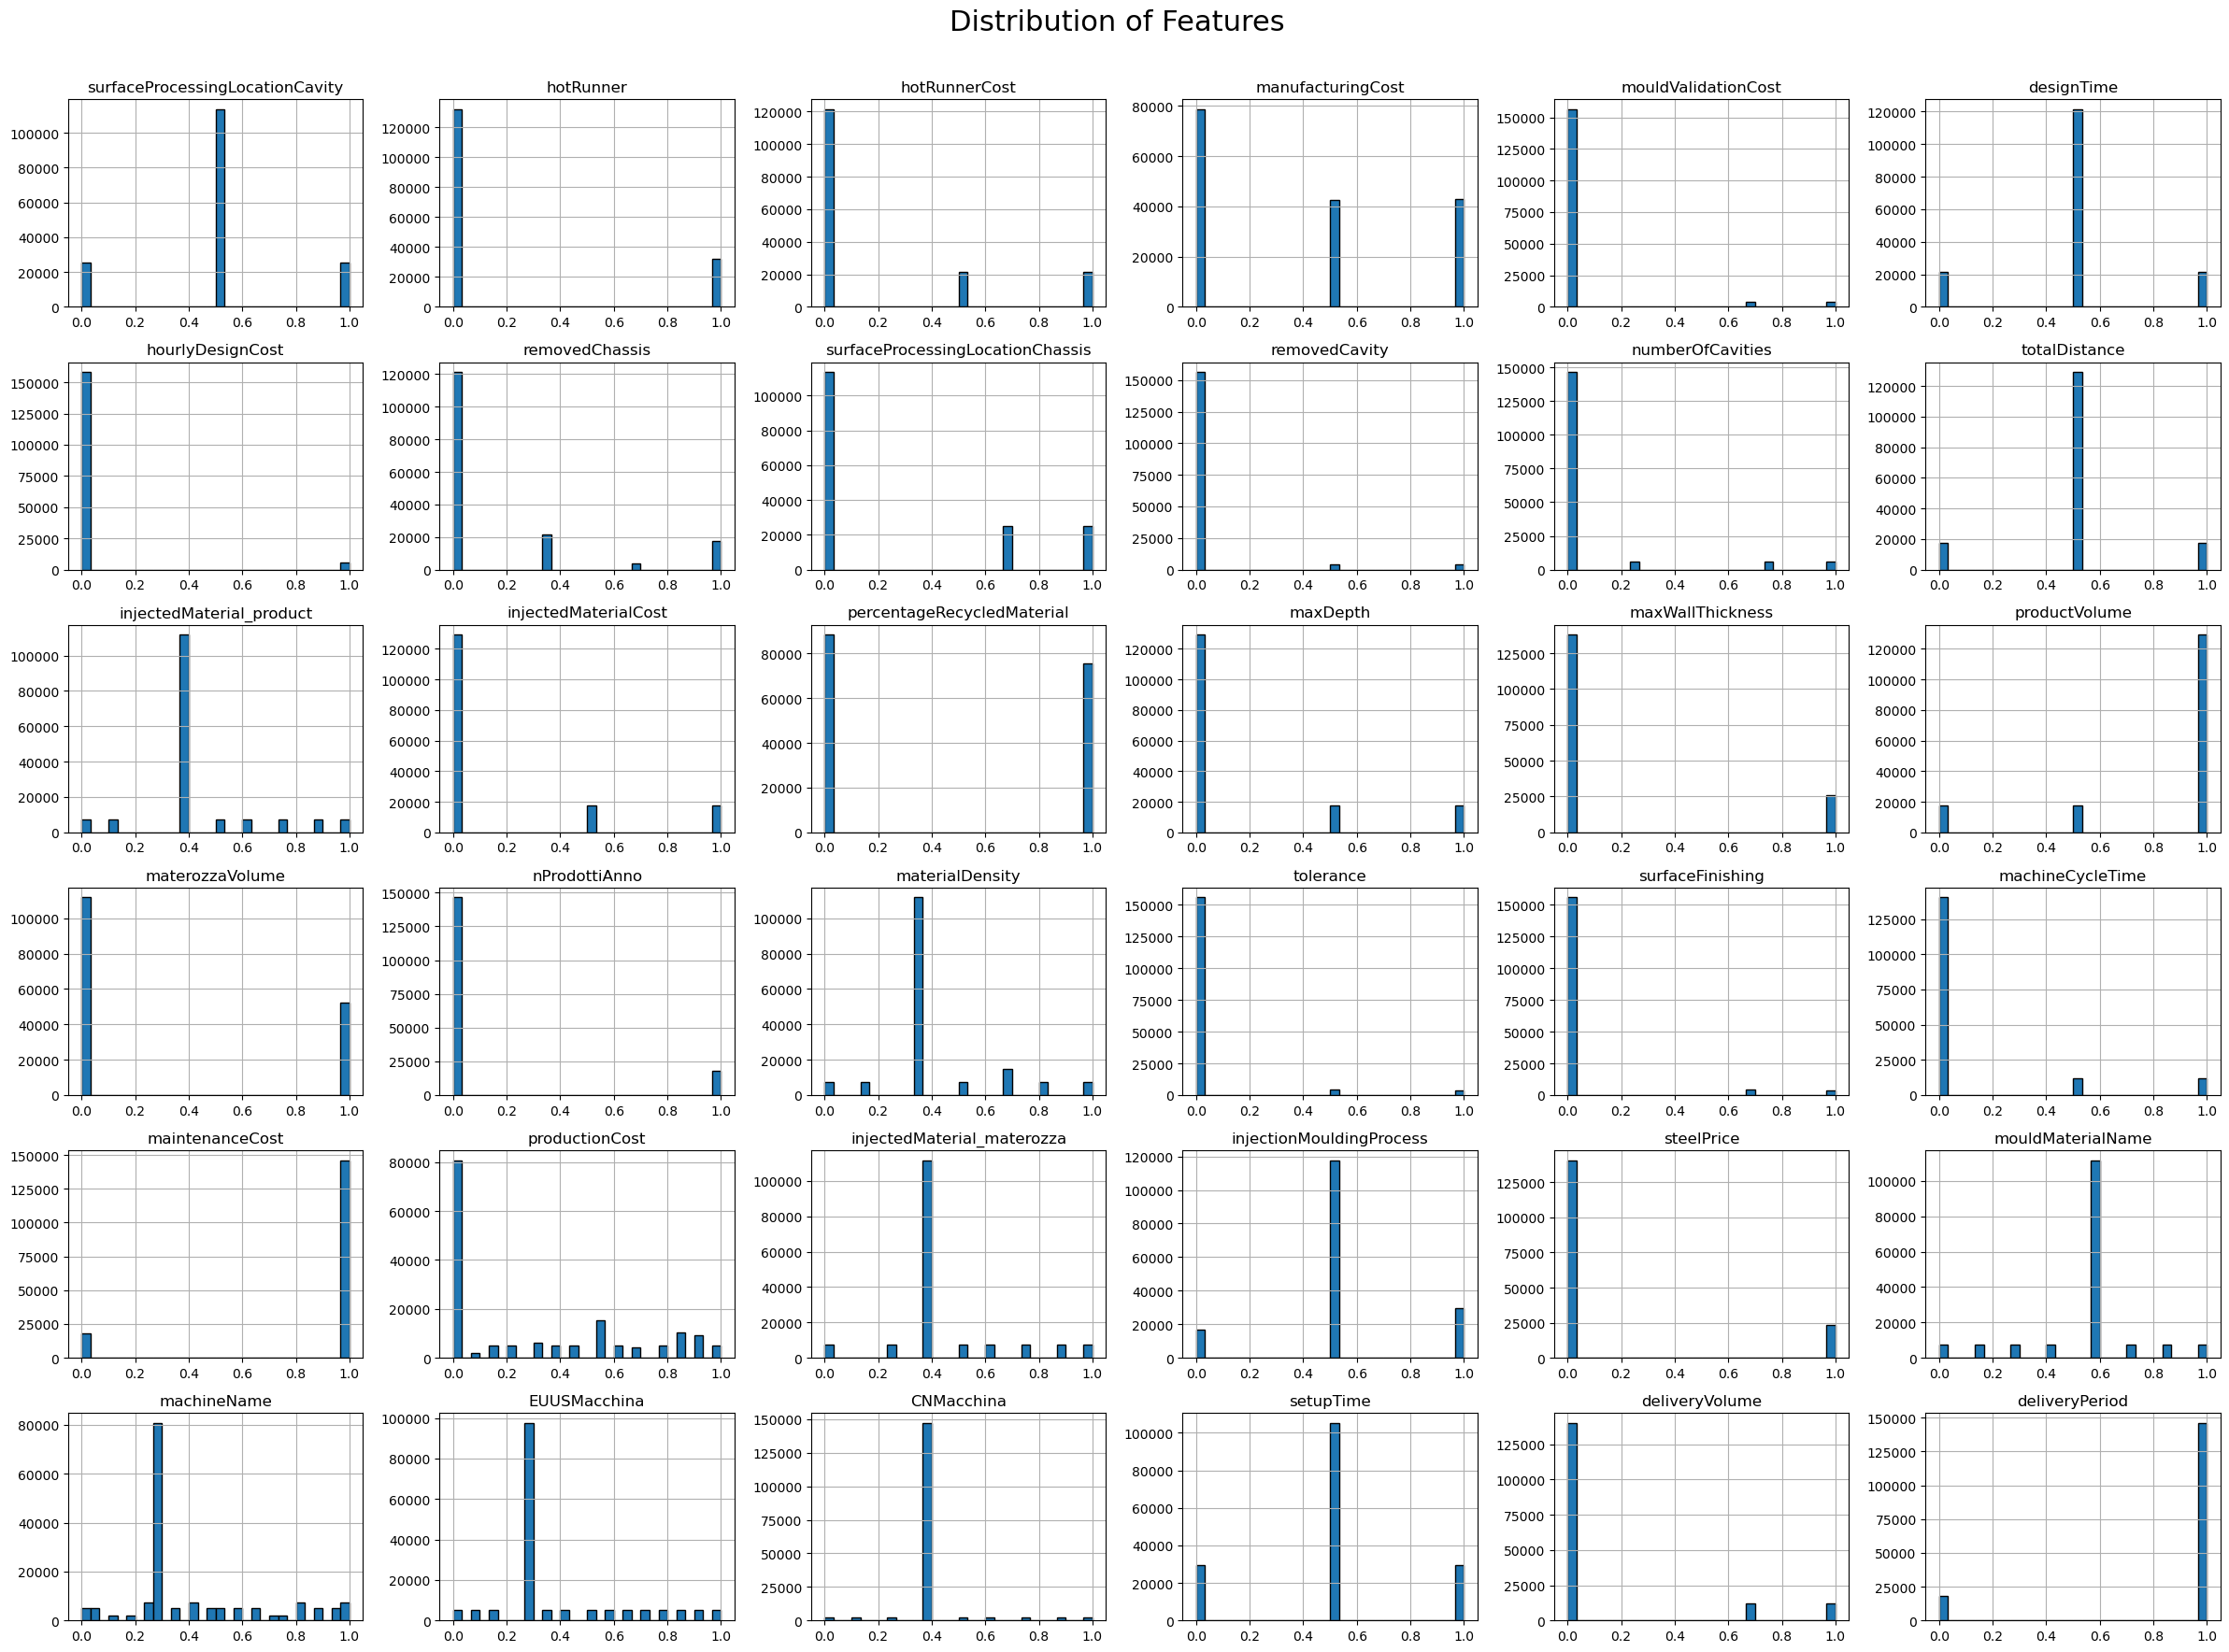

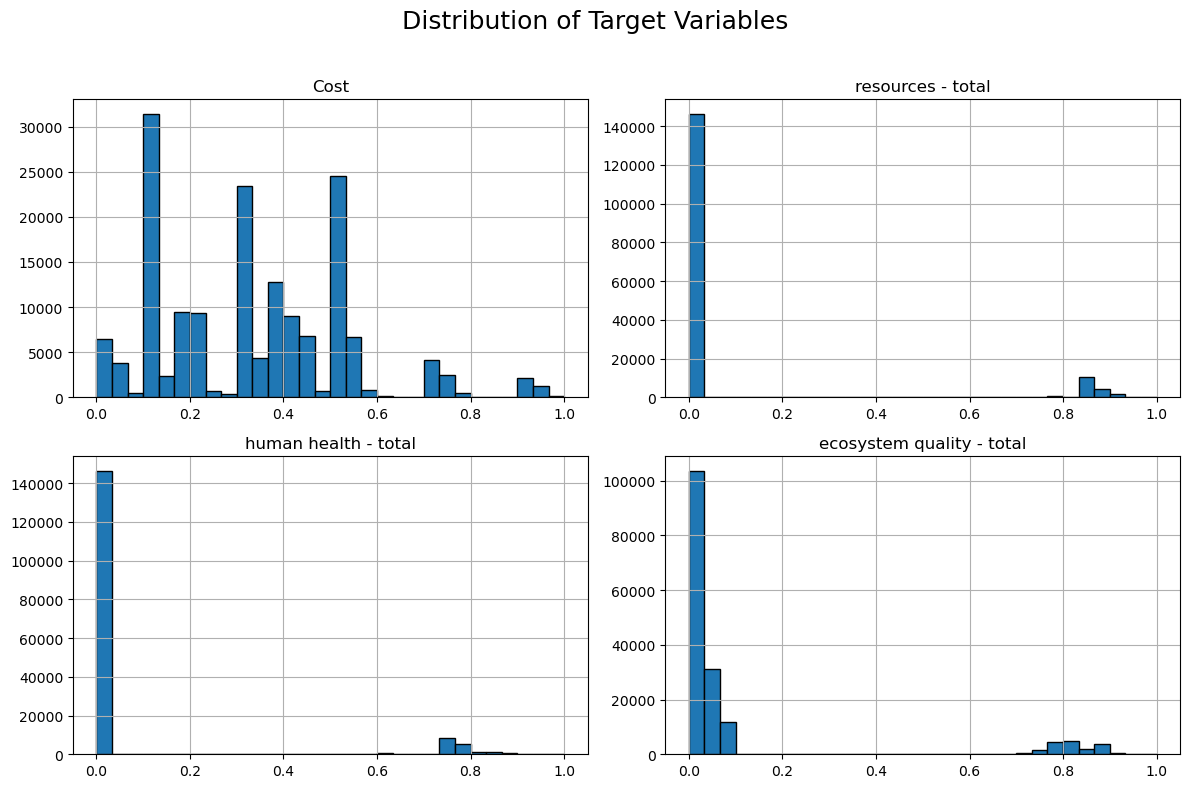

In [101]:
# Plot and save the distribution of all features
features_plot_path = os.path.join(outputs_path, "features_distribution.png")
ax_features = features.hist(figsize=(24, 18), bins=30, layout=(6, 6), edgecolor='black')
plt.suptitle('Distribution of Features', fontsize=22)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.savefig(features_plot_path)
plt.show()

# Plot and save the distribution of all target variables
target_plot_path = os.path.join(outputs_path, "target_distribution.png")
ax_target = target.hist(figsize=(12, 8), bins=30, layout=(2, 2), edgecolor='black')
plt.suptitle('Distribution of Target Variables', fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(target_plot_path)
plt.show()

In [76]:
target

,Cost,resources - total,human health - total,ecosystem quality - total
0,0.201290,0.000318,0.001123,0.003202
1,0.038710,0.000030,0.000054,0.000038
2,0.806452,0.000317,0.001119,0.003192
3,0.058065,0.000192,0.000675,0.001926
4,0.349677,0.000190,0.000671,0.001915
...,...,...,...,...
164143,0.038711,0.004132,0.007575,0.005611
164144,0.322581,0.006991,0.012244,0.006554
164145,0.554839,0.004038,0.010265,0.077022
164146,0.406452,0.000804,0.002974,0.046709


In [77]:
features

,surfaceProcessingLocationCavity,hotRunner,hotRunnerCost,manufacturingCost,mouldValidationCost,designTime,hourlyDesignCost,removedChassis,surfaceProcessingLocationChassis,removedCavity,numberOfCavities,totalDistance,injectedMaterial_product,injectedMaterialCost,percentageRecycledMaterial,maxDepth,maxWallThickness,productVolume,materozzaVolume,nProdottiAnno,materialDensity,tolerance,surfaceFinishing,machineCycleTime,maintenanceCost,productionCost,injectedMaterial_materozza,injectionMouldingProcess,steelPrice,mouldMaterialName,machineName,EUUSMacchina,CNMacchina,setupTime,deliveryVolume,deliveryPeriod
0,0.5,1.0,1.0,0.5,0.000000,0.5,1.0,0.666667,0.0,1.0,0.75,0.5,0.375,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.333333,0.0,0.0,0.0,1.0,0.000000,0.375,0.5,0.0,0.571429,0.294118,0.285714,0.375,0.5,0.0,1.0
1,0.5,1.0,1.0,0.0,0.666667,1.0,0.0,0.000000,0.0,1.0,0.25,0.5,0.375,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.333333,0.0,0.0,0.0,1.0,0.000000,0.375,0.5,0.0,0.571429,0.294118,0.285714,0.375,0.5,0.0,1.0
2,0.5,0.0,1.0,0.5,1.000000,0.0,1.0,0.666667,0.0,0.0,0.75,0.5,0.375,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.333333,0.0,0.0,0.0,1.0,0.000000,0.375,0.5,0.0,0.571429,0.294118,0.285714,0.375,0.5,0.0,1.0
3,0.5,1.0,0.0,0.0,1.000000,1.0,0.0,0.333333,0.0,1.0,0.75,0.5,0.375,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.333333,0.0,0.0,0.0,1.0,0.000000,0.375,0.5,0.0,0.571429,0.294118,0.285714,0.375,0.5,0.0,1.0
4,0.5,0.0,0.5,0.0,0.666667,0.5,1.0,0.333333,0.0,0.0,0.75,0.5,0.375,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.333333,0.0,0.0,0.0,1.0,0.000000,0.375,0.5,0.0,0.571429,0.294118,0.285714,0.375,0.5,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164143,0.5,1.0,0.0,0.0,0.000000,0.0,0.0,0.333333,0.0,0.0,0.00,0.5,0.375,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.333333,0.0,0.0,0.0,1.0,0.846154,0.375,1.0,0.0,0.571429,0.941176,0.928571,0.375,1.0,0.0,1.0
164144,0.5,0.0,0.0,0.5,0.000000,0.5,0.0,0.000000,0.0,0.0,0.00,0.5,0.375,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.333333,0.0,0.0,0.0,1.0,0.230769,0.375,1.0,0.0,0.571429,0.823529,0.785714,0.375,0.0,0.0,1.0
164145,0.0,0.0,0.0,1.0,0.000000,0.0,0.0,1.000000,1.0,0.0,0.00,0.5,0.375,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.333333,0.0,0.0,0.0,1.0,0.153846,0.375,0.5,0.0,0.571429,0.588235,0.642857,0.375,1.0,0.0,1.0
164146,0.0,1.0,1.0,1.0,0.000000,1.0,0.0,0.000000,1.0,0.0,0.00,0.5,0.375,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.333333,0.0,0.0,0.0,1.0,0.153846,0.375,0.5,0.0,0.571429,0.588235,0.642857,0.375,0.5,0.0,1.0


In [78]:
df_selected = pd.concat([features, target], axis=1)

In [79]:
df_selected.head()

,surfaceProcessingLocationCavity,hotRunner,hotRunnerCost,manufacturingCost,mouldValidationCost,designTime,hourlyDesignCost,removedChassis,surfaceProcessingLocationChassis,removedCavity,numberOfCavities,totalDistance,injectedMaterial_product,injectedMaterialCost,percentageRecycledMaterial,maxDepth,maxWallThickness,productVolume,materozzaVolume,nProdottiAnno,materialDensity,tolerance,surfaceFinishing,machineCycleTime,maintenanceCost,productionCost,injectedMaterial_materozza,injectionMouldingProcess,steelPrice,mouldMaterialName,machineName,EUUSMacchina,CNMacchina,setupTime,deliveryVolume,deliveryPeriod,Cost,resources - total,human health - total,ecosystem quality - total
0,0.5,1.0,1.0,0.5,0.000000,0.5,1.0,0.666667,0.0,1.0,0.75,0.5,0.375,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.333333,0.0,0.0,0.0,1.0,0.0,0.375,0.5,0.0,0.571429,0.294118,0.285714,0.375,0.5,0.0,1.0,0.201290,0.000318,0.001123,0.003202
1,0.5,1.0,1.0,0.0,0.666667,1.0,0.0,0.000000,0.0,1.0,0.25,0.5,0.375,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.333333,0.0,0.0,0.0,1.0,0.0,0.375,0.5,0.0,0.571429,0.294118,0.285714,0.375,0.5,0.0,1.0,0.038710,0.000030,0.000054,0.000038
2,0.5,0.0,1.0,0.5,1.000000,0.0,1.0,0.666667,0.0,0.0,0.75,0.5,0.375,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.333333,0.0,0.0,0.0,1.0,0.0,0.375,0.5,0.0,0.571429,0.294118,0.285714,0.375,0.5,0.0,1.0,0.806452,0.000317,0.001119,0.003192
3,0.5,1.0,0.0,0.0,1.000000,1.0,0.0,0.333333,0.0,1.0,0.75,0.5,0.375,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.333333,0.0,0.0,0.0,1.0,0.0,0.375,0.5,0.0,0.571429,0.294118,0.285714,0.375,0.5,0.0,1.0,0.058065,0.000192,0.000675,0.001926
4,0.5,0.0,0.5,0.0,0.666667,0.5,1.0,0.333333,0.0,0.0,0.75,0.5,0.375,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.333333,0.0,0.0,0.0,1.0,0.0,0.375,0.5,0.0,0.571429,0.294118,0.285714,0.375,0.5,0.0,1.0,0.349677,0.000190,0.000671,0.001915


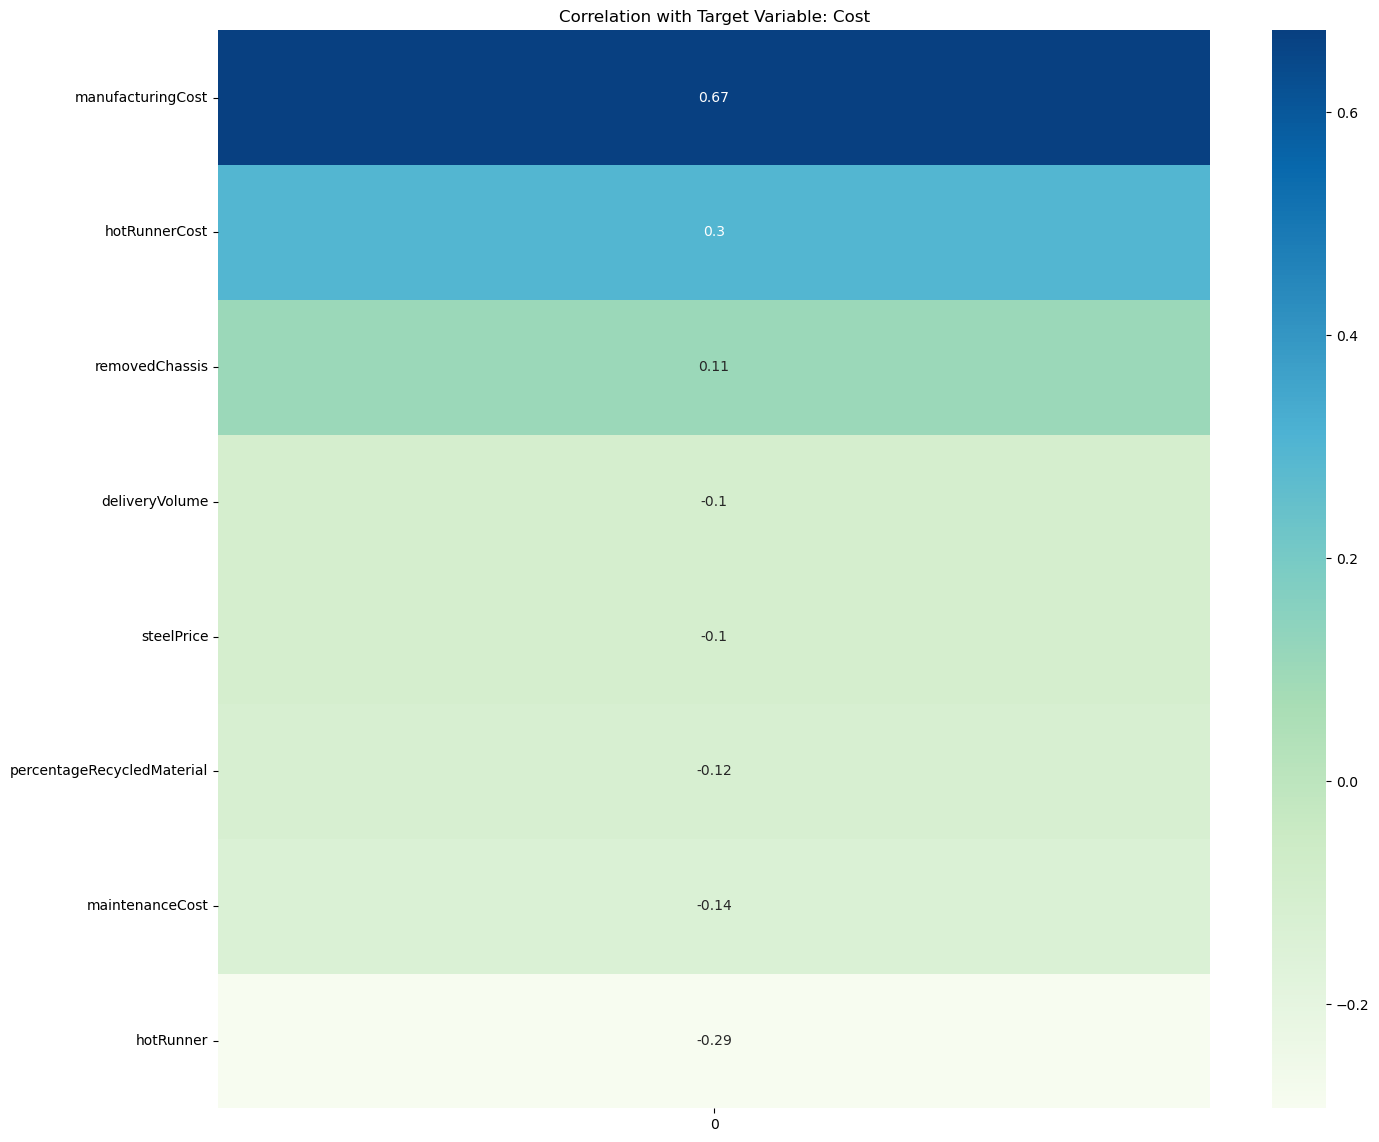

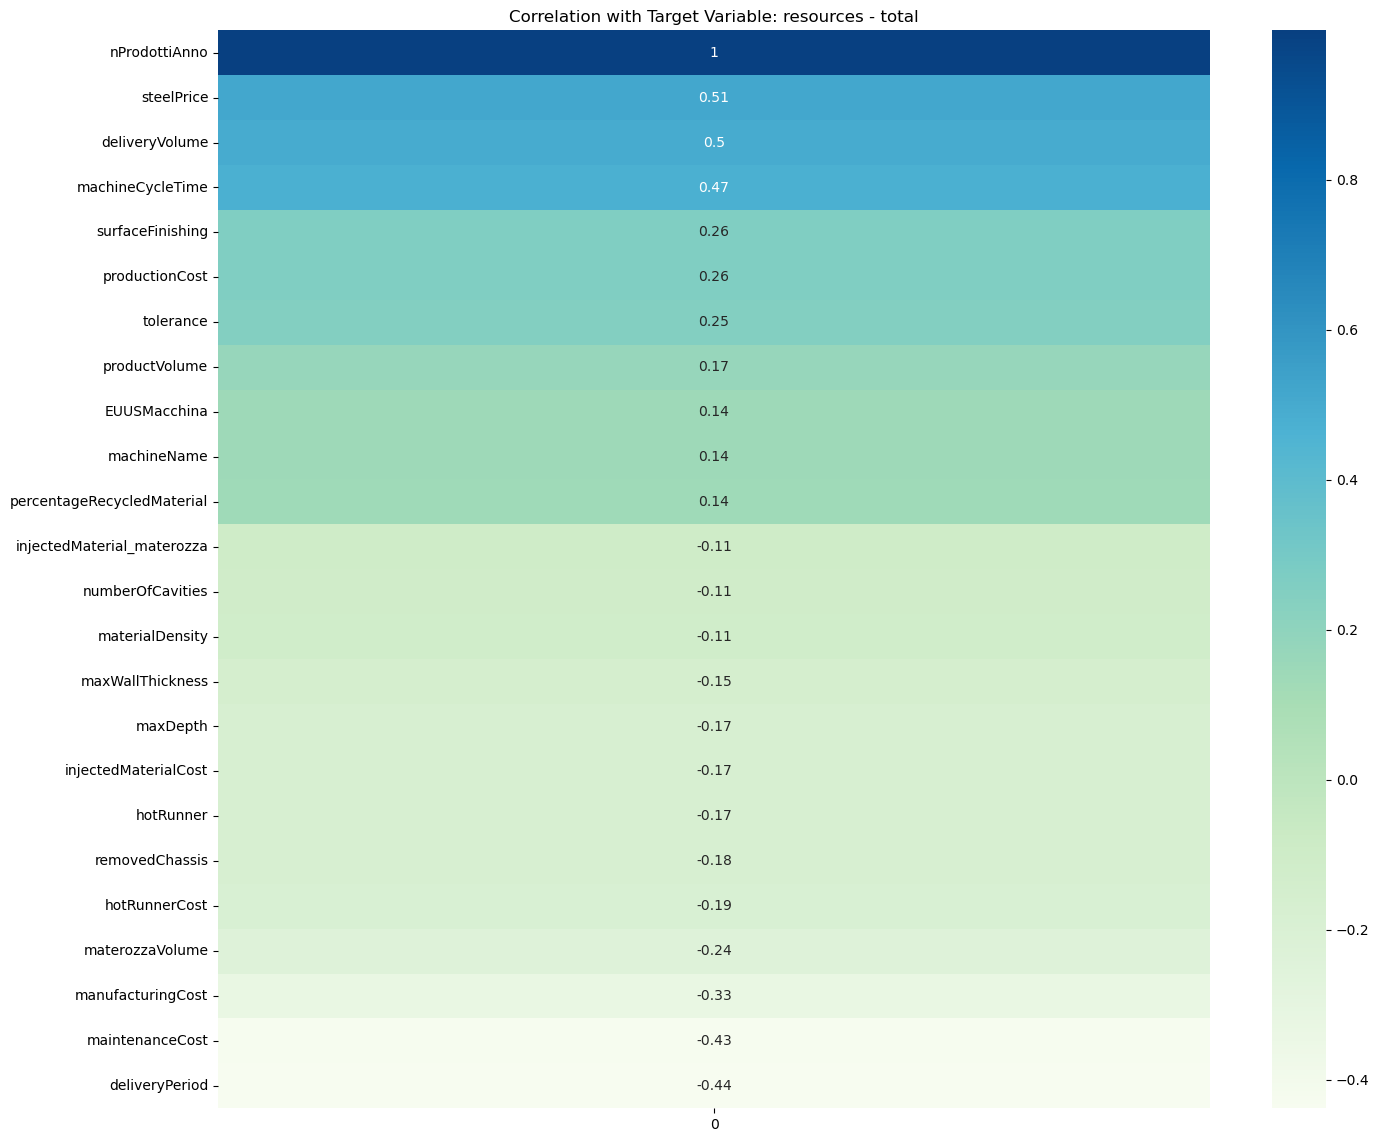

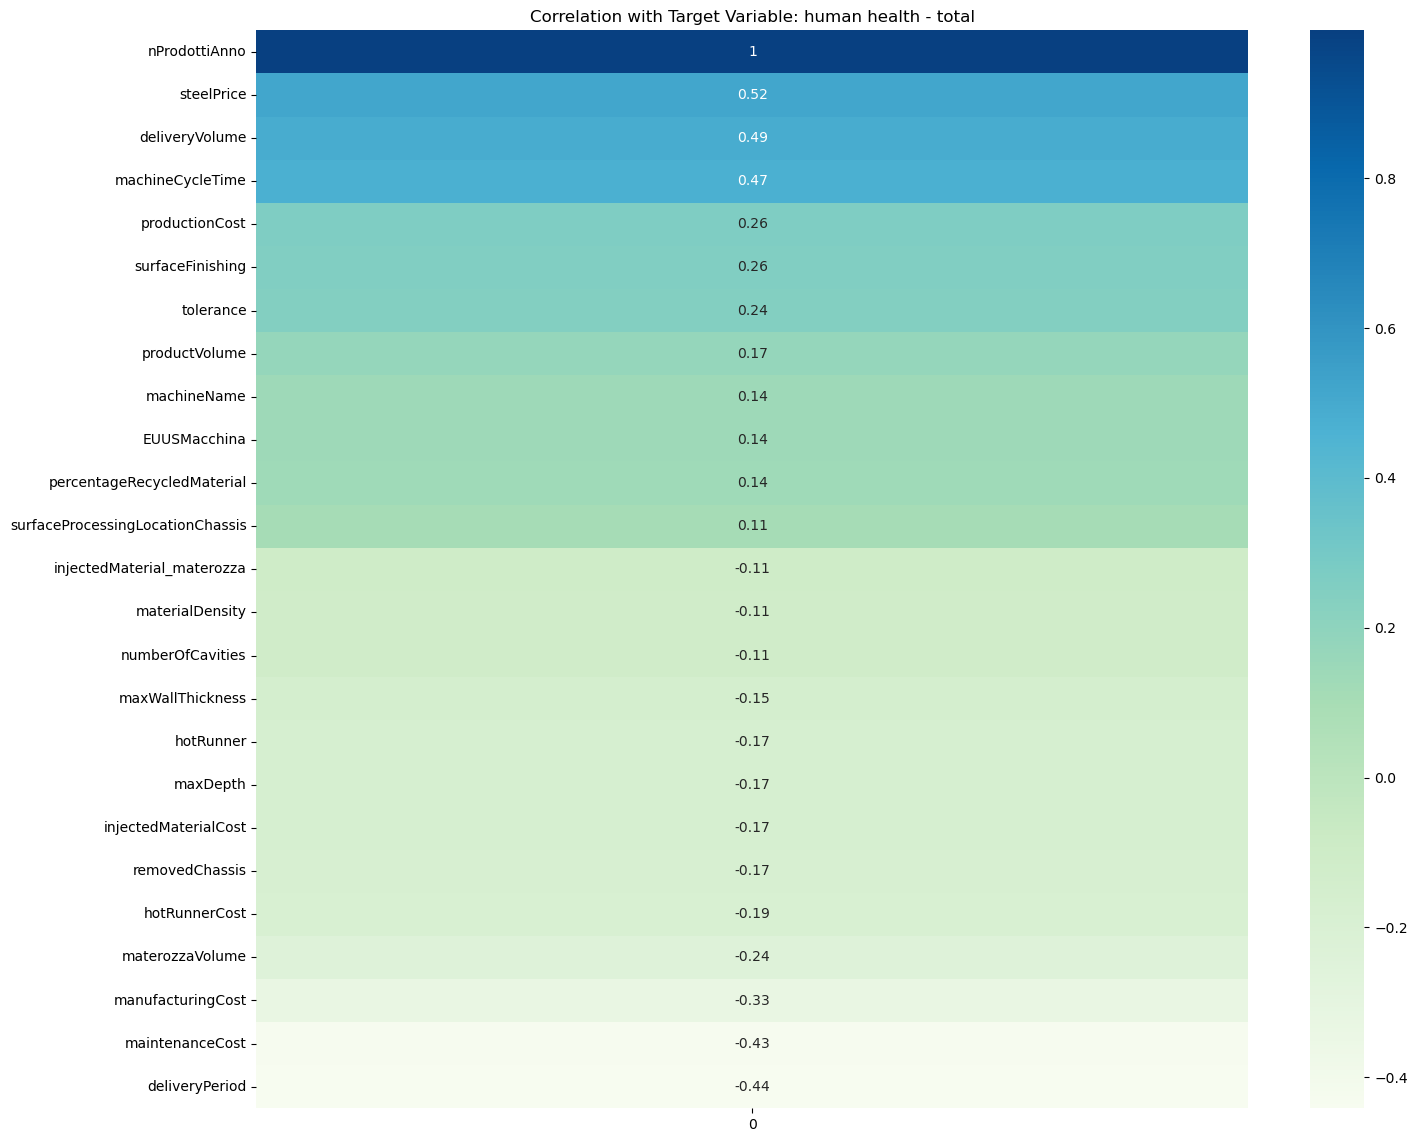

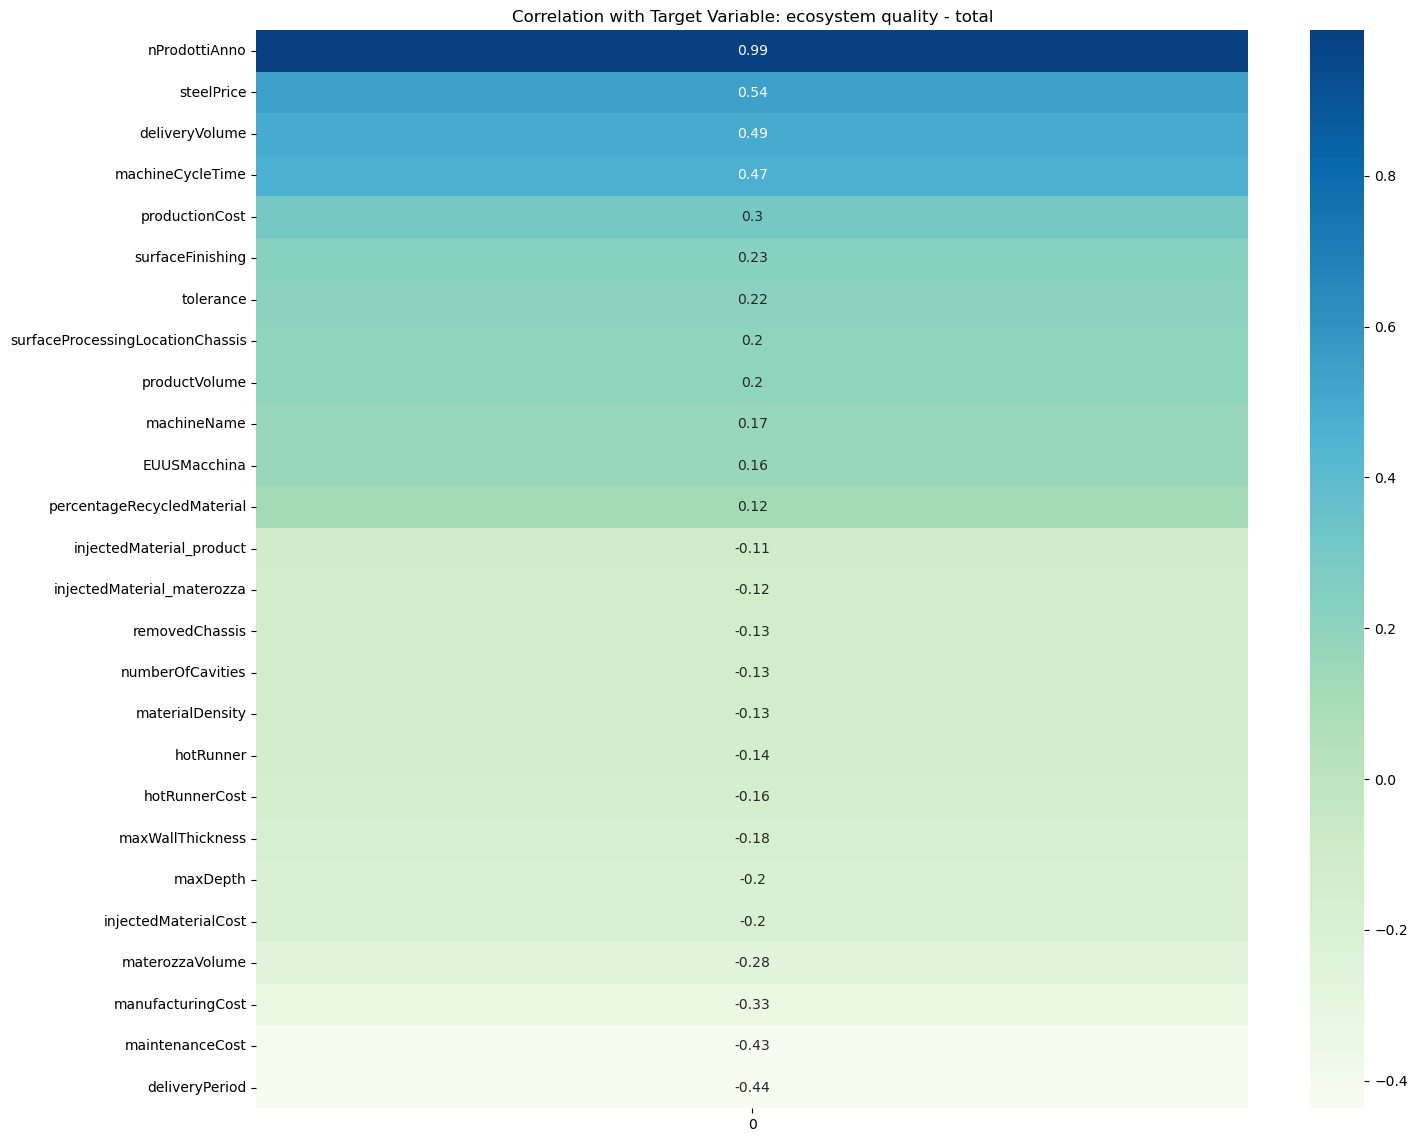

In [92]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Dictionary to store filtered correlations
filtered_correlations = {}

# Assuming target is a DataFrame with multiple columns
for column in target.columns:
    # Calculate correlation with the specific target variable
    corr_with_target = features.corrwith(target[column])
    
    # Filter correlations: keep only those >= 0.1 or <= -0.1
    filtered_corr = corr_with_target[(corr_with_target >= 0.1) | (corr_with_target <= -0.1)]
    
    # Store the filtered correlations in a dictionary
    filtered_correlations[column] = filtered_corr
    
    # Sort the filtered correlations
    filtered_corr = filtered_corr.sort_values(ascending=False)
    
    # Check if there are any correlations to plot
    if not filtered_corr.empty:
        # Plot the heatmap for this target variable
        plt.figure(figsize=(16, 14))
        sns.heatmap(filtered_corr.to_frame(), cmap='GnBu', annot=True)
        plt.title(f'Correlation with Target Variable: {column}')
        plt.savefig(os.path.join(outputs_path, f"pearson_corr_with_{column}.png"))
        #plt.show()
    else:
        print(f"No features with correlation >= 0.1 or <= -0.1 for {column}")

# After loop, you can access filtered_correlations for each target variable


In [99]:
print(filtered_correlations['Cost'])


hotRunner                    -0.293572
hotRunnerCost                 0.295903
manufacturingCost             0.673537
removedChassis                0.106163
percentageRecycledMaterial   -0.115544
maintenanceCost              -0.137321
steelPrice                   -0.102010
deliveryVolume               -0.102004
dtype: float64


In [100]:
target.columns

Index(['Cost', 'resources - total', 'human health - total',
       'ecosystem quality - total'],
      dtype='object')

In [102]:
features_human_health_total = filtered_correlations['human health - total'].index,
features_ecosystem_quality_total = filtered_correlations['ecosystem quality - total'].index,
features_resources_total = filtered_correlations['resources - total'].index,
features_cost = filtered_correlations['Cost'].index
print(features_human_health_total)
print(features_ecosystem_quality_total)
print(features_resources_total)
print(features_cost)


(Index(['hotRunner', 'hotRunnerCost', 'manufacturingCost', 'removedChassis',
       'surfaceProcessingLocationChassis', 'numberOfCavities',
       'injectedMaterialCost', 'percentageRecycledMaterial', 'maxDepth',
       'maxWallThickness', 'productVolume', 'materozzaVolume', 'nProdottiAnno',
       'materialDensity', 'tolerance', 'surfaceFinishing', 'machineCycleTime',
       'maintenanceCost', 'productionCost', 'injectedMaterial_materozza',
       'steelPrice', 'machineName', 'EUUSMacchina', 'deliveryVolume',
       'deliveryPeriod'],
      dtype='object'),)
(Index(['hotRunner', 'hotRunnerCost', 'manufacturingCost', 'removedChassis',
       'surfaceProcessingLocationChassis', 'numberOfCavities',
       'injectedMaterial_product', 'injectedMaterialCost',
       'percentageRecycledMaterial', 'maxDepth', 'maxWallThickness',
       'productVolume', 'materozzaVolume', 'nProdottiAnno', 'materialDensity',
       'tolerance', 'surfaceFinishing', 'machineCycleTime', 'maintenanceCost',
       '

In [104]:
# List to store concatenated results
concat_results = []

for i in filtered_correlations:
    # Initialize a temporary DataFrame for each iteration over filtered_correlations
    temp_df = pd.DataFrame()

    for j in selected_features:
        # Concatenate selected features and store them temporarily
        temp_df = pd.concat([temp_df, df_scaled[[j]]], axis=1)

    # Concatenate the result of filtered_correlations column as well
    temp_df = pd.concat([temp_df, df_scaled[[i]]], axis=1)
    
    # Append the resulting DataFrame to the results list
    concat_results.append(temp_df)

# Concatenate all results into a single DataFrame
final_df = pd.concat(concat_results, axis=0, ignore_index=True)

print("\nFinal concatenated DataFrame:")
final_df.head()


Final concatenated DataFrame:


,surfaceProcessingLocationCavity,hotRunner,hotRunnerCost,manufacturingCost,mouldValidationCost,designTime,hourlyDesignCost,removedChassis,surfaceProcessingLocationChassis,removedCavity,numberOfCavities,totalDistance,injectedMaterial_product,injectedMaterialCost,percentageRecycledMaterial,maxDepth,maxWallThickness,productVolume,materozzaVolume,nProdottiAnno,materialDensity,tolerance,surfaceFinishing,machineCycleTime,maintenanceCost,productionCost,injectedMaterial_materozza,injectionMouldingProcess,steelPrice,mouldMaterialName,machineName,EUUSMacchina,CNMacchina,setupTime,deliveryVolume,deliveryPeriod,Cost,resources - total,human health - total,ecosystem quality - total
0,0.5,1.0,1.0,0.5,0.000000,0.5,1.0,0.666667,0.0,1.0,0.75,0.5,0.375,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.333333,0.0,0.0,0.0,1.0,0.0,0.375,0.5,0.0,0.571429,0.294118,0.285714,0.375,0.5,0.0,1.0,0.201290,NaN,NaN,NaN
1,0.5,1.0,1.0,0.0,0.666667,1.0,0.0,0.000000,0.0,1.0,0.25,0.5,0.375,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.333333,0.0,0.0,0.0,1.0,0.0,0.375,0.5,0.0,0.571429,0.294118,0.285714,0.375,0.5,0.0,1.0,0.038710,NaN,NaN,NaN
2,0.5,0.0,1.0,0.5,1.000000,0.0,1.0,0.666667,0.0,0.0,0.75,0.5,0.375,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.333333,0.0,0.0,0.0,1.0,0.0,0.375,0.5,0.0,0.571429,0.294118,0.285714,0.375,0.5,0.0,1.0,0.806452,NaN,NaN,NaN
3,0.5,1.0,0.0,0.0,1.000000,1.0,0.0,0.333333,0.0,1.0,0.75,0.5,0.375,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.333333,0.0,0.0,0.0,1.0,0.0,0.375,0.5,0.0,0.571429,0.294118,0.285714,0.375,0.5,0.0,1.0,0.058065,NaN,NaN,NaN
4,0.5,0.0,0.5,0.0,0.666667,0.5,1.0,0.333333,0.0,0.0,0.75,0.5,0.375,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.333333,0.0,0.0,0.0,1.0,0.0,0.375,0.5,0.0,0.571429,0.294118,0.285714,0.375,0.5,0.0,1.0,0.349677,NaN,NaN,NaN


In [105]:
final_df.shape

(656592, 40)